# **Introduction to Language Models**

If you are viewing this notebook on Google Colab (or any other cloud vendor), you need to uncomment and run the following codeblock to install the dependencies for this chapter:

In [1]:
%%capture
!pip install transformers==4.41.2 accelerate==0.31.0

**go to Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4.**

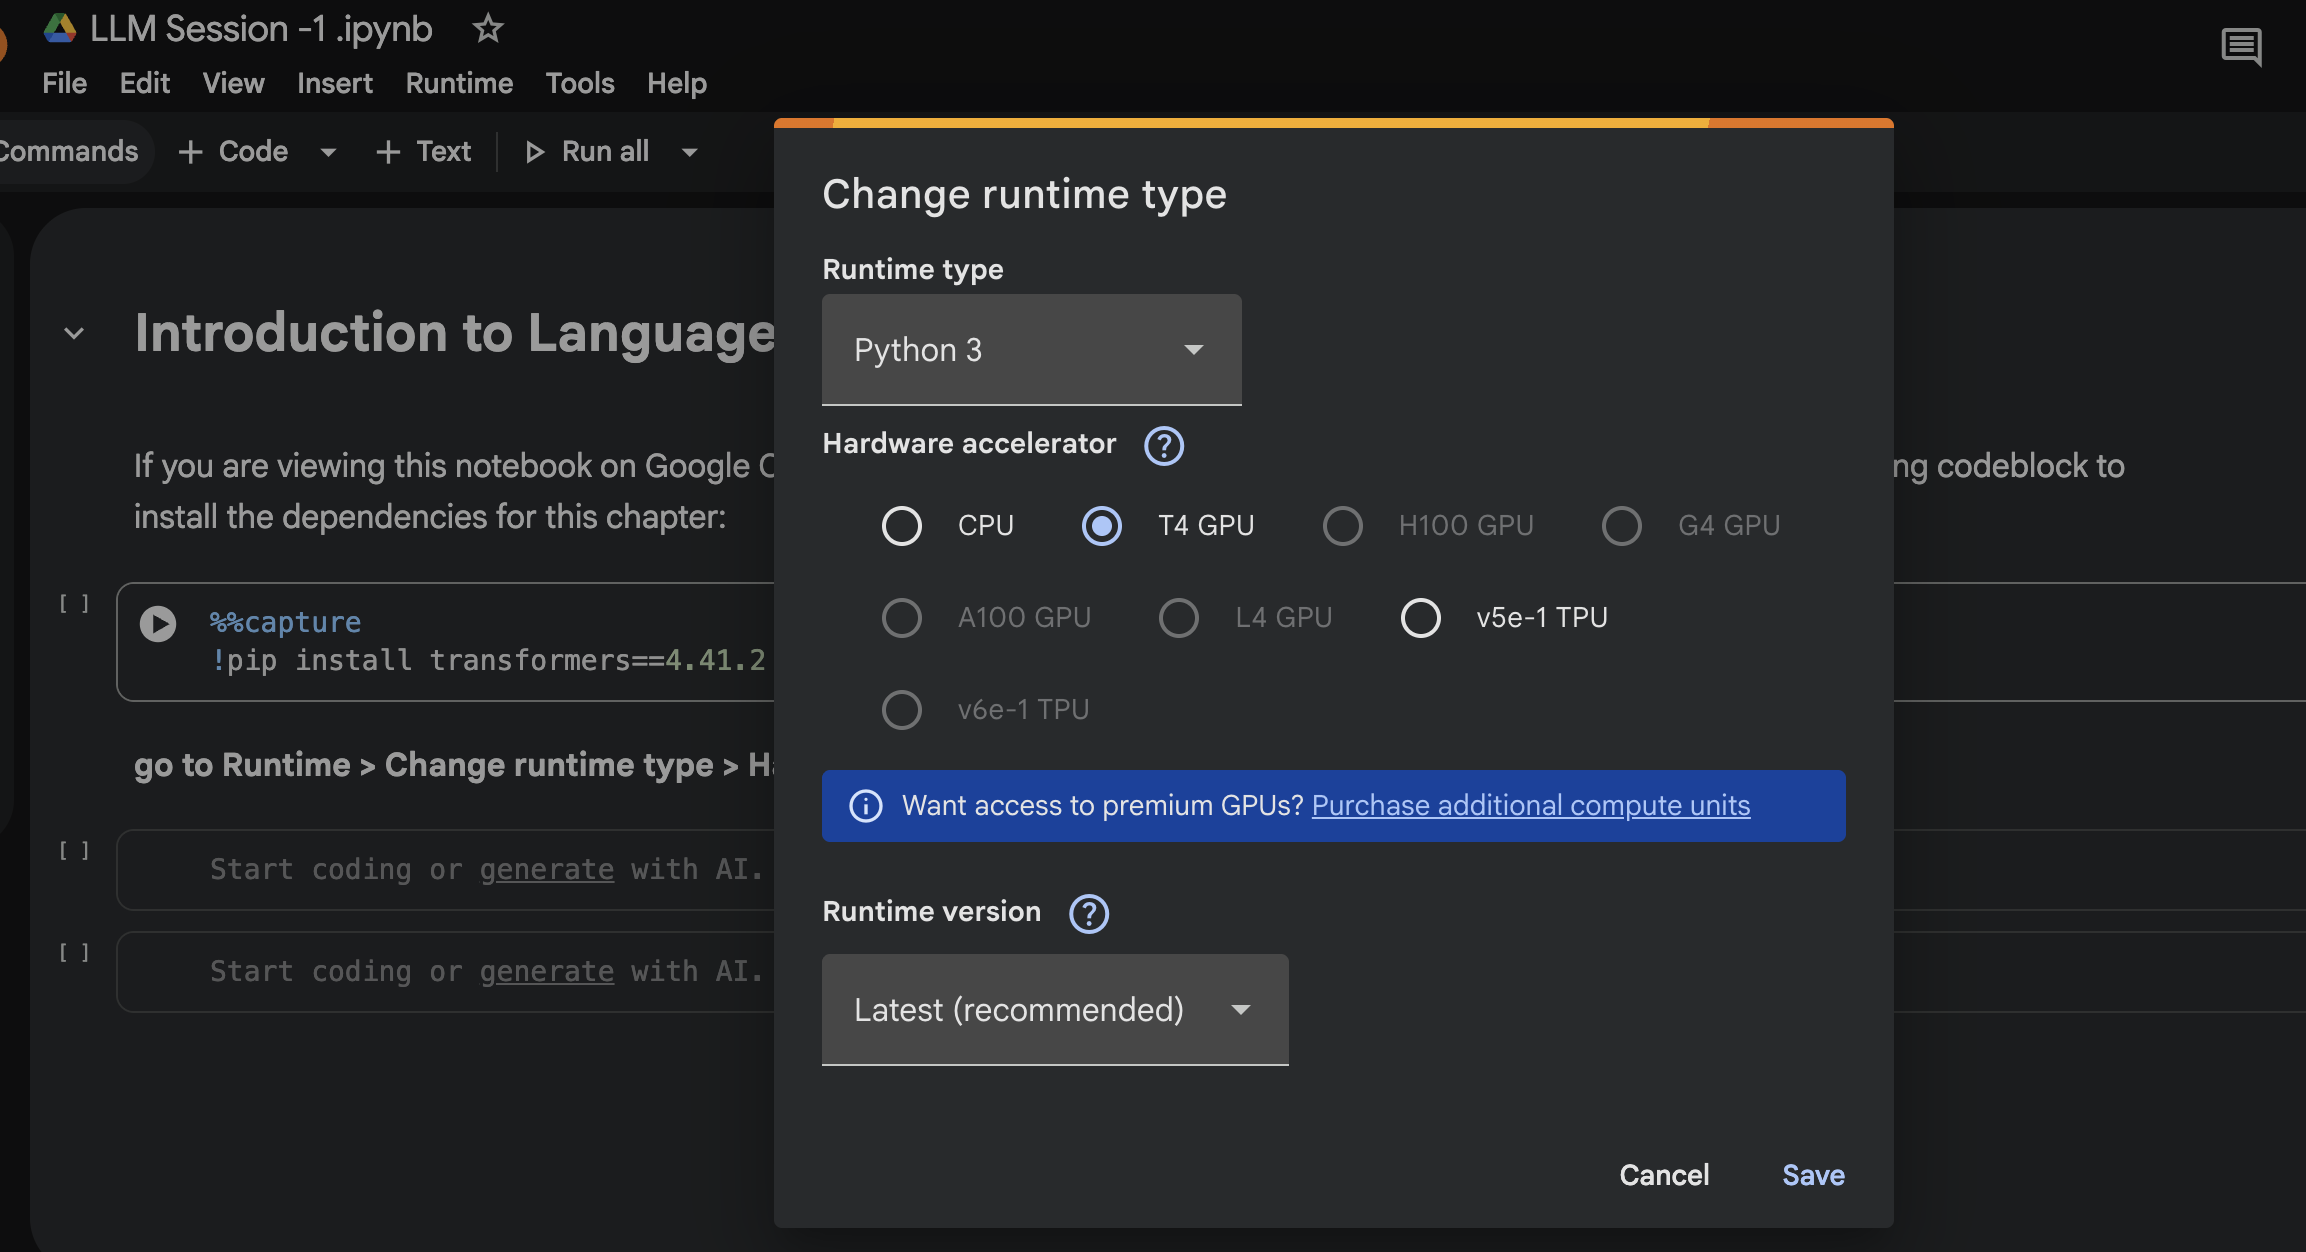

The first step is to load our model onto the GPU for faster inference. Note that we load the model and tokenizer separately (although that isn't always necessary).

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

In [3]:
# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

We loads a pre-trained language model and its tokenizer from Hugging Face Transformers.

Specifically, it loads the `'microsoft/Phi-3-mini-4k-instruct'` model and its corresponding tokenizer. The model is loaded onto the GPU ('cuda') for faster inference, with the torch data type automatically determined.

Although we can now use the model and tokenizer directly, it's much easier to wrap it in a pipeline object:

In [4]:
from transformers import pipeline

# Create a pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False
)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


This cell initializes a text generation pipeline using the Hugging Face Transformers `pipeline` function.
It configures the pipeline with the previously loaded model and tokenizer for text generation tasks.
Key parameters set include `return_full_text=False` (to get only the generated text),
`max_new_tokens=500` (to limit the length of generated output), and `do_sample=False` (for deterministic generation).

Finally, we create our prompt as a user and give it to the model:

In [5]:
# The prompt (user input / query)
messages = [
    {"role": "user", "content": "Create a funny joke about chickens."}
]

# Generate output
output = generator(messages)
print(output[0]["generated_text"])

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Why did the chicken join the band? Because it had the drumsticks!


In this step, we're essentially having a conversation with our language model!

First, we craft a simple message, asking the model to 'Create a funny joke about chickens.'

Then, we feed this message into our `generator` (which is our language model in action) to get a response.

Finally, we take the generated joke from the model's output and display it for everyone to see.